# 1×8 MMI Splitter — Stage 1 v2: Topology + Geometry Joint Optimization

**vs v1:**
1. **Uniformity penalty** `J = total × (1 - α × norm_CV²)` — prevents power concentrating in outer ports
2. **Joint geometry optimization** via central-difference FD every 8 topo iters:
   - `port_pitch` ∈ [1.20, 1.85] µm
   - `wg_w_in` ∈ [0.80, 1.50] µm
   - `wg_w_out` ∈ [0.80, 1.50] µm

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import json, os
from scipy.optimize import brentq
from scipy.ndimage import gaussian_filter
import meep as mp
import meep.adjoint as mpa
from autograd import numpy as npa

mp.verbosity(0)

OUT  = '/mnt/c/Users/Hemera/Projects/meep_1x8_progress'
OUTV = f'{OUT}/stage1_v2'
os.makedirs(OUTV, exist_ok=True)

Using MPI version 4.0, 1 processes


In [2]:
# Platform
lam0=1.55; n_SiN=1.996; n_SiO2=1.444; t_SiN=0.8
k0 = 2*np.pi/lam0
def slab_eq(neff):
    ky=k0*np.sqrt(n_SiN**2-neff**2); gm=k0*np.sqrt(neff**2-n_SiO2**2)
    return np.tan(ky*t_SiN/2)-gm/ky
n_eff_2d = brentq(slab_eq, 1.82, 1.99)
print(f'n_eff = {n_eff_2d:.4f}')
SiN_mat=mp.Medium(index=n_eff_2d); SiO2_mat=mp.Medium(index=n_SiO2)
freq0=1.0/lam0

n_eff = 1.8836


In [3]:
# Fixed layout
N_out=8; mmi_W=14.0; mmi_L=30.0; wg_ext=4.0; pml_th=2.0; resolution=15
sx=mmi_L+2*wg_ext+2*pml_th; sy=mmi_W+2*pml_th
des_res=8; Nx_des=int(mmi_L*des_res); Ny_des=int(mmi_W*des_res)
filter_sig=0.3*des_res
src_x=-(mmi_L/2+wg_ext*0.5); mon_x=mmi_L/2+wg_ext*0.5
print(f'Grid: {Nx_des}x{Ny_des}  cell: {sx:.0f}x{sy:.0f} um')

Grid: 240x112  cell: 42x18 um


In [4]:
# Learnable geometry parameters
geo = {'port_pitch': 1.75, 'wg_w_in': 1.0, 'wg_w_out': 1.0}
GEO_BOUNDS   = {'port_pitch': (1.20, 1.85), 'wg_w_in': (0.80, 1.50), 'wg_w_out': (0.80, 1.50)}
GEO_DELTA    = {'port_pitch': 0.03, 'wg_w_in': 0.05, 'wg_w_out': 0.05}
GEO_LR       = 0.005
GEO_INTERVAL = 8
geo_m={k:0.0 for k in geo}; geo_v={k:0.0 for k in geo}; geo_step=0

def get_port_ys(pitch):
    return np.array([i-(N_out-1)/2 for i in range(N_out)])*pitch

In [5]:
# Schedules
def get_beta(i):
    if i<30: return 4
    if i<55: return 8
    if i<80: return 16
    return 32

def get_alpha(i):
    """Uniformity weight. Max safe value = 1/(N-1) ≈ 0.143 for N=8."""
    if i<20: return 0.0
    if i<50: return 0.05
    return 0.12

# Objective (autograd-compatible)
_alpha_val = 0.0
EPS_J = 1e-10

def J(*args):
    powers   = npa.array([npa.abs(npa.squeeze(a))**2 for a in args])
    total    = npa.sum(powers)
    mean     = total/N_out
    norm_var = npa.sum((powers-mean)**2)/(N_out*mean**2+EPS_J)
    return total*(1.0 - _alpha_val*norm_var)

In [6]:
# Filter + projection
def sigmoid_project(x2d, beta, eta=0.5):
    xf=gaussian_filter(x2d,sigma=filter_sig)
    num=np.tanh(beta*eta)+np.tanh(beta*(xf-eta))
    den=np.tanh(beta*eta)+np.tanh(beta*(1.0-eta))
    return num/den

def backprop_gradient(x2d, dJ_flat, beta, eta=0.5):
    xf=gaussian_filter(x2d,sigma=filter_sig)
    dsig=beta*(1-np.tanh(beta*(xf-eta))**2)
    dsig/=np.tanh(beta*eta)+np.tanh(beta*(1.0-eta))
    return gaussian_filter(dsig*dJ_flat.reshape(Ny_des,Nx_des),sigma=filter_sig).flatten()

In [7]:
# OptimizationProblem factory
def build_opt(geo_d, x_proj_flat):
    port_ys_l=get_port_ys(geo_d['port_pitch'])
    wg_w_in=geo_d['wg_w_in']; wg_w_out=geo_d['wg_w_out']
    dvars=mp.MaterialGrid(mp.Vector3(Nx_des,Ny_des),SiO2_mat,SiN_mat,
        weights=x_proj_flat.reshape(Ny_des,Nx_des),do_averaging=True)
    dreg=mpa.DesignRegion(dvars,
        volume=mp.Volume(center=mp.Vector3(),size=mp.Vector3(mmi_L,mmi_W)))
    geom=[
        mp.Block(size=mp.Vector3(wg_ext+pml_th,wg_w_in),
                 center=mp.Vector3(-(mmi_L/2+(wg_ext+pml_th)/2),0),material=SiN_mat),
        mp.Block(size=mp.Vector3(mmi_L,mmi_W),center=mp.Vector3(),material=dvars),
    ]
    for y in port_ys_l:
        geom.append(mp.Block(size=mp.Vector3(wg_ext+pml_th,wg_w_out),
                             center=mp.Vector3(mmi_L/2+(wg_ext+pml_th)/2,y),material=SiN_mat))
    src=[mp.EigenModeSource(mp.GaussianSource(freq0,fwidth=0.05*freq0),
        size=mp.Vector3(0,wg_w_in*4),center=mp.Vector3(src_x,0),
        eig_match_freq=True,eig_parity=mp.ODD_Z)]
    sim=mp.Simulation(cell_size=mp.Vector3(sx,sy),boundary_layers=[mp.PML(pml_th)],
        geometry=geom,sources=src,default_material=SiO2_mat,resolution=resolution)
    ob=[mpa.EigenmodeCoefficient(sim,mp.Volume(center=mp.Vector3(mon_x,y),
        size=mp.Vector3(0,wg_w_out*4)),1,eig_parity=mp.ODD_Z,forward=True)
        for y in port_ys_l]
    opt_obj=mpa.OptimizationProblem(simulation=sim,objective_functions=J,
        objective_arguments=ob,design_regions=[dreg],frequencies=[freq0])
    return opt_obj, dvars, port_ys_l

In [8]:
# Forward-only J for geometry FD (1 sim, no adjoint)
def run_forward_J(geo_d, x, beta, alpha_val):
    port_ys_l=get_port_ys(geo_d['port_pitch'])
    wg_w_in=geo_d['wg_w_in']; wg_w_out=geo_d['wg_w_out']
    xp=sigmoid_project(x.reshape(Ny_des,Nx_des),beta).flatten()
    dvars_t=mp.MaterialGrid(mp.Vector3(Nx_des,Ny_des),SiO2_mat,SiN_mat,
        weights=xp.reshape(Ny_des,Nx_des),do_averaging=True)
    geom_t=[
        mp.Block(size=mp.Vector3(wg_ext+pml_th,wg_w_in),
                 center=mp.Vector3(-(mmi_L/2+(wg_ext+pml_th)/2),0),material=SiN_mat),
        mp.Block(size=mp.Vector3(mmi_L,mmi_W),center=mp.Vector3(),material=dvars_t),
    ]
    for y in port_ys_l:
        geom_t.append(mp.Block(size=mp.Vector3(wg_ext+pml_th,wg_w_out),
                               center=mp.Vector3(mmi_L/2+(wg_ext+pml_th)/2,y),material=SiN_mat))
    src_t=[mp.EigenModeSource(mp.GaussianSource(freq0,fwidth=0.05*freq0),
        size=mp.Vector3(0,wg_w_in*4),center=mp.Vector3(src_x,0),
        eig_match_freq=True,eig_parity=mp.ODD_Z)]
    sim_t=mp.Simulation(cell_size=mp.Vector3(sx,sy),boundary_layers=[mp.PML(pml_th)],
        geometry=geom_t,sources=src_t,default_material=SiO2_mat,resolution=resolution)
    mon_w=min(wg_w_out*1.4, geo_d['port_pitch']*0.75)
    mon_in_t=sim_t.add_flux(freq0,0,1,
        mp.FluxRegion(center=mp.Vector3(src_x+1.0,0),size=mp.Vector3(0,wg_w_in*4)))
    mon_outs_t=[sim_t.add_flux(freq0,0,1,
        mp.FluxRegion(center=mp.Vector3(mon_x,y),size=mp.Vector3(0,mon_w)))
        for y in port_ys_l]
    sim_t.run(until_after_sources=mp.stop_when_fields_decayed(
        50,mp.Ez,mp.Vector3(mon_x,port_ys_l[0]),1e-4))
    P_in=mp.get_fluxes(mon_in_t)[0]
    if P_in<=0: return 0.0
    P_outs=np.array([mp.get_fluxes(m)[0] for m in mon_outs_t])
    powers=P_outs/P_in; total=float(np.sum(powers)); mean=total/N_out
    norm_var=float(np.sum((powers-mean)**2)/(N_out*mean**2+EPS_J))
    return total*(1.0-alpha_val*norm_var)

In [9]:
# Progress saver
def save_progress(i, x, hist, geo_d, port_ys_l):
    beta=get_beta(i)
    x2d=sigmoid_project(x.reshape(Ny_des,Nx_des),beta)
    ext=[-mmi_L/2,mmi_L/2,-mmi_W/2,mmi_W/2]
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    axes[0].imshow(x2d,origin='lower',cmap='RdBu_r',vmin=0,vmax=1,extent=ext)
    geo_str=(f'pitch={geo_d["port_pitch"]:.3f}  '
             f'w_in={geo_d["wg_w_in"]:.3f}  w_out={geo_d["wg_w_out"]:.3f}')
    axes[0].set_title(f'Stage 1 v2  iter {i}  alpha={get_alpha(i):.2f}\n{geo_str}')
    axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('y (µm)')
    for y in port_ys_l: axes[0].axhline(y,color='yellow',lw=0.6,ls='--',alpha=0.7)
    axes[1].plot(hist,'b-',lw=1.5)
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('J')
    axes[1].set_title(f'J={hist[-1]:.2f}'); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTV}/progress_iter{i:03d}.png',dpi=110,bbox_inches='tight')
    plt.savefig(f'{OUTV}/progress_latest.png',dpi=110,bbox_inches='tight')
    plt.close(fig)
    with open(f'{OUTV}/log.json','w') as f:
        json.dump({'iter':i,'J_history':hist,'beta':beta,'alpha':get_alpha(i),
                   'geo':geo_d,'port_ys':port_ys_l.tolist()},f)
    np.save(f'{OUTV}/x_latest.npy',x)

In [10]:
# Initialize
n_iters=100; lr_topo=0.02; save_every=5
b1,b2,eps_a=0.9,0.999,1e-8
x=np.ones(Nx_des*Ny_des)*0.5
m_ax=np.zeros_like(x); v_ax=np.zeros_like(x)
hist=[]
xp_init=sigmoid_project(x.reshape(Ny_des,Nx_des),get_beta(0)).flatten()
opt,design_variables,port_ys=build_opt(geo,xp_init)
print(f'Initial geo: {geo}')
print(f'Est. total sims: {n_iters*2+(n_iters//GEO_INTERVAL)*len(geo)*2}')

Initial geo: {'port_pitch': 1.75, 'wg_w_in': 1.0, 'wg_w_out': 1.0}
Est. total sims: 272


In [11]:
# Main optimization loop
for i in range(n_iters):
    beta=get_beta(i); alpha=get_alpha(i); _alpha_val=alpha
    x2d=x.reshape(Ny_des,Nx_des); xp=sigmoid_project(x2d,beta).flatten()

    # Topology adjoint
    f_val,dJ=opt([xp])
    grad=backprop_gradient(x2d,np.asarray(dJ).flatten(),beta)
    m_ax=b1*m_ax+(1-b1)*grad; v_ax=b2*v_ax+(1-b2)*grad**2
    m_h=m_ax/(1-b1**(i+1)); v_h=v_ax/(1-b2**(i+1))
    x=np.clip(x+lr_topo*m_h/(np.sqrt(v_h)+eps_a),0,1)
    hist.append(float(f_val))

    # Geometry FD update
    if (i+1)%GEO_INTERVAL==0:
        geo_step+=1
        print(f'  [geo update @ iter {i}  beta={beta}  alpha={alpha:.2f}]')
        geo_grad={}
        for param in geo:
            delta=GEO_DELTA[param]
            geo_p={**geo,param:min(geo[param]+delta,GEO_BOUNDS[param][1])}
            geo_n={**geo,param:max(geo[param]-delta,GEO_BOUNDS[param][0])}
            Jp=run_forward_J(geo_p,x,beta,alpha)
            Jn=run_forward_J(geo_n,x,beta,alpha)
            geo_grad[param]=(Jp-Jn)/(geo_p[param]-geo_n[param])
            print(f'    {param}: J+={Jp:.4f}  J-={Jn:.4f}  grad={geo_grad[param]:.4f}')
        for param in geo:
            geo_m[param]=b1*geo_m[param]+(1-b1)*geo_grad[param]
            geo_v[param]=b2*geo_v[param]+(1-b2)*geo_grad[param]**2
            m_h_g=geo_m[param]/(1-b1**geo_step)
            v_h_g=geo_v[param]/(1-b2**geo_step)
            geo[param]+=GEO_LR*m_h_g/(np.sqrt(v_h_g)+eps_a)
            lo,hi=GEO_BOUNDS[param]
            geo[param]=float(np.clip(geo[param],lo,hi))
        port_ys=get_port_ys(geo['port_pitch'])
        xp_new=sigmoid_project(x.reshape(Ny_des,Nx_des),beta).flatten()
        opt,design_variables,port_ys=build_opt(geo,xp_new)
        print(f'  Updated geo: {geo}')

    print(f'  Iter {i:3d} | beta={beta:2d} | alpha={alpha:.2f} | J={float(f_val):.2f}')
    if i%save_every==0 or i==n_iters-1:
        save_progress(i,x,hist,geo,port_ys)

Starting forward run...
Starting adjoint run...
Calculating gradient...
  Iter   0 | beta= 4 | alpha=0.00 | J=565.45
Starting forward run...
Starting adjoint run...
Calculating gradient...
  Iter   1 | beta= 4 | alpha=0.00 | J=739.05
Starting forward run...
Starting adjoint run...
Calculating gradient...
  Iter   2 | beta= 4 | alpha=0.00 | J=839.80
Starting forward run...
Starting adjoint run...
Calculating gradient...
  Iter   3 | beta= 4 | alpha=0.00 | J=893.42
Starting forward run...
Starting adjoint run...
Calculating gradient...
  Iter   4 | beta= 4 | alpha=0.00 | J=944.37
Starting forward run...
Starting adjoint run...
Calculating gradient...
  Iter   5 | beta= 4 | alpha=0.00 | J=1018.55
Starting forward run...
Starting adjoint run...
Calculating gradient...
  Iter   6 | beta= 4 | alpha=0.00 | J=1110.69
Starting forward run...
Starting adjoint run...
Calculating gradient...
  [geo update @ iter 7  beta=4  alpha=0.00]
    port_pitch: J+=0.8931  J-=0.8805  grad=0.2103
    wg_w_in: 

    wg_w_out: J+=0.8843  J-=0.8840  grad=0.0031
  Updated geo: {'port_pitch': 1.7549999997622183, 'wg_w_in': 1.0049999984169455, 'wg_w_out': 1.0049999837809651}
  Iter   7 | beta= 4 | alpha=0.00 | J=1205.80
Starting forward run...


Starting adjoint run...


Calculating gradient...
  Iter   8 | beta= 4 | alpha=0.00 | J=1293.23
Starting forward run...


Starting adjoint run...


...

Starting adjoint run...


Calculating gradient...


  Iter  98 | beta=32 | alpha=0.12 | J=1673.10
Starting forward run...


Starting adjoint run...


Calculating gradient...
  Iter  99 | beta=32 | alpha=0.12 | J=1677.54


In [12]:
# Save final results
np.save(f'{OUTV}/x_final_v2.npy', x)
with open(f'{OUTV}/geo_final_v2.json','w') as f:
    json.dump({'geo':geo,'port_ys':port_ys.tolist(),
               'J_initial':hist[0],'J_final':hist[-1]},f,indent=2)
print(f'Done. J: {hist[0]:.2f} → {hist[-1]:.2f}')
print(f'Final geo: {geo}')
print(f'Results: {OUTV}')

Done. J: 565.45 → 1677.54
Final geo: {'port_pitch': 1.7976416751650703, 'wg_w_in': 1.008844880139456, 'wg_w_out': 0.9970864385589009}
Results: /mnt/c/Users/Hemera/Projects/meep_1x8_progress/stage1_v2


Gray fraction: 10.4%


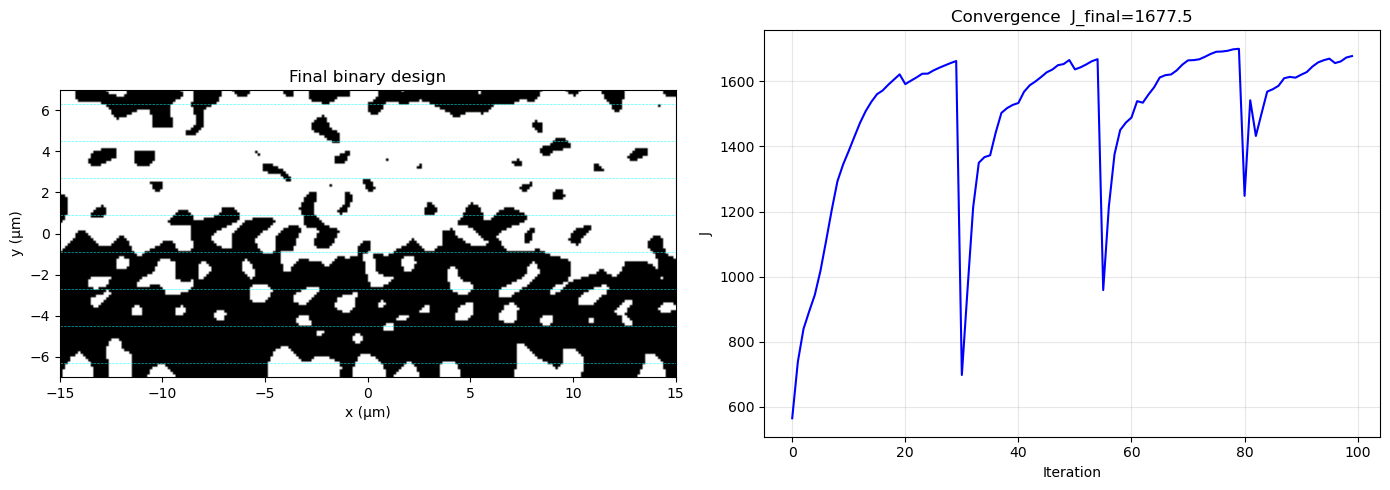

In [13]:
# Show final design
%matplotlib inline
beta_f=64; eta=0.5
x2d_f=x.reshape(Ny_des,Nx_des)
xf_f=gaussian_filter(x2d_f,sigma=filter_sig)
x_soft=(np.tanh(beta_f*eta)+np.tanh(beta_f*(xf_f-eta)))/(np.tanh(beta_f*eta)+np.tanh(beta_f*(1-eta)))
x_bin=(x_soft>0.5).astype(float)
gray_frac=np.mean((x_soft>0.05)&(x_soft<0.95))
print(f'Gray fraction: {100*gray_frac:.1f}%')

fig,axes=plt.subplots(1,2,figsize=(14,5))
ext=[-mmi_L/2,mmi_L/2,-mmi_W/2,mmi_W/2]
axes[0].imshow(x_bin,origin='lower',cmap='binary_r',extent=ext)
axes[0].set_title('Final binary design')
axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('y (µm)')
for y in port_ys: axes[0].axhline(y,color='cyan',lw=0.5,ls='--',alpha=0.7)
axes[1].plot(hist,'b-',lw=1.5)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('J')
axes[1].set_title(f'Convergence  J_final={hist[-1]:.1f}')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()